In [21]:
# step1_redthreads.ipynb
import numpy as np, pandas as pd

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from core.viz import plot_competency_effects, plot_competency_delta_bar
from core import io as IO
from core.io import (
    fetch_for_competency_eda, 
    fetch_for_psych_eda, 
    fetch_for_strengths_eda,
    fetch_for_contextual_eda
    )
from core.eda_competency import build_abt_competency, summarize_competency
from core.eda_psych import summarize_papi, summarize_cognitive
from core.eda_strengths import summarize_strengths
from core.eda_contextual import summarize_contextual
from core.evaluate import evaluate_all
from core.success_formula import compute_success_score_from_fetchers

import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, auc, precision_recall_curve

# Competency Pillars

Kompetensi (skill-based pattern) apa yang paling membedakan karyawan dengan performa tinggi (rating 5) dari yang lain?

In [4]:
d = fetch_for_competency_eda()
abt = build_abt_competency(d)
comp_tbl = summarize_competency(abt, d["dim_comp_labels"])

In [5]:
comp_tbl.head(20)

,pillar_code,pillar_label,mean_high,mean_non,delta,cohens_d,p_mwu,n_high,n_non
0,SEA,Social Empathy & Awareness,5.234177,2.927775,2.306403,0.946072,1.250072e-63,158,1703
1,CEX,Curiosity & Experimentation,4.539474,2.965962,1.573511,0.631032,3.538349e-55,152,1704
2,VCU,Value Creation for Users,5.197452,3.175563,2.021889,0.396571,1.849590e-59,157,1686
3,STO,Synergy & Team Orientation,5.106250,3.149761,1.956489,0.383014,7.253751e-58,160,1676
4,CSI,Commercial Savvy & Impact,5.241830,3.219715,2.022115,0.362712,1.874813e-60,153,1684
5,QDD,Quality Delivery Discipline,4.691824,3.162114,1.529710,0.332387,3.677093e-67,159,1684
6,GDR,Growth Drive & Resilience,4.550336,3.132749,1.417587,0.309388,1.062192e-56,149,1710
7,LIE,"Lead, Inspire & Empower",4.581699,3.181926,1.399774,0.304665,2.840418e-58,153,1693
8,IDS,Insight & Decision Sharpness,4.535484,3.140000,1.395484,0.304058,2.062898e-57,155,1700
9,FTC,Forward Thinking & Clarity,4.548387,3.169601,1.378786,0.300755,5.030228e-56,155,1704


Tabel ini menampilkan hasil perbandingan **rata-rata skor 10 pilar kompetensi**
antara dua kelompok karyawan:

- **High performers** -> karyawan dengan `rating = 5`
- **Non-high performers** -> karyawan dengan `rating ≠ 5`

Tujuannya adalah untuk menemukan **pilar kompetensi yang paling membedakan**
antara kedua kelompok tersebut.

| Kolom | Makna | Cara Baca |
|:------|:------|:----------|
| `pillar_code` | Kode singkat pilar kompetensi (mis. SEA, CEX, dll.) | Identitas tiap pilar |
| `pillar_label` | Nama lengkap pilar | Berguna untuk storytelling dan visualisasi |
| `mean_high` / `mean_non` | Nilai rata-rata skor pilar per grup | Rata-rata kompetensi untuk high vs non-high |
| `delta` | Selisih (`mean_high - mean_non`) | Semakin besar -> pilar makin membedakan |
| `cohens_d` | *Effect size* (kekuatan perbedaan) | ≥0.8 besar, ≈0.5 sedang, <0.3 kecil |
| `p_mwu` | Nilai *p-value* uji Mann–Whitney U | <0.05 artinya perbedaan signifikan |
| `n_high` / `n_non` | Jumlah responden per grup | Validasi ukuran sampel |

---

## Interpretasi

Hasil analisis menunjukkan bahwa:

- **SEA (Social Empathy & Awareness)** memiliki *effect size* tertinggi (`d ≈ 0.95`),  
  artinya empati sosial dan kesadaran terhadap orang lain sangat kuat membedakan high performer.
- **CEX (Curiosity & Experimentation)** juga tinggi (`d ≈ 0.63`),  
  menunjukkan bahwa rasa ingin tahu dan kemauan untuk bereksperimen menjadi ciri khas performer unggul.
- Pilar seperti **VCU, STO, dan CSI** (`d ≈ 0.36–0.40`) memberi kontribusi sedang namun tetap signifikan.
- Pilar lain seperti **GDR, LIE, IDS, FTC** (`d ≈ 0.30`) tetap positif, namun pengaruhnya relatif kecil.

Semua nilai *p-value* berada di bawah 0.05, artinya perbedaan ini signifikan secara statistik.

---

### Kesimpulan Sementara

High performers secara konsisten menunjukkan keunggulan pada pilar:

> **SEA -> CEX -> VCU/STO/CSI**

Kombinasi ini menggambarkan pola **empati sosial**, **rasa ingin tahu**, dan **orientasi nilai pelanggan**  
sebagai *red thread* utama dari keberhasilan karyawan.

Nilai `cohens_d` dan `delta` dari tabel ini akan menjadi dasar awal dalam penentuan **bobot TV**  
untuk TGV **Competency** di *Success Formula* tahap berikutnya.

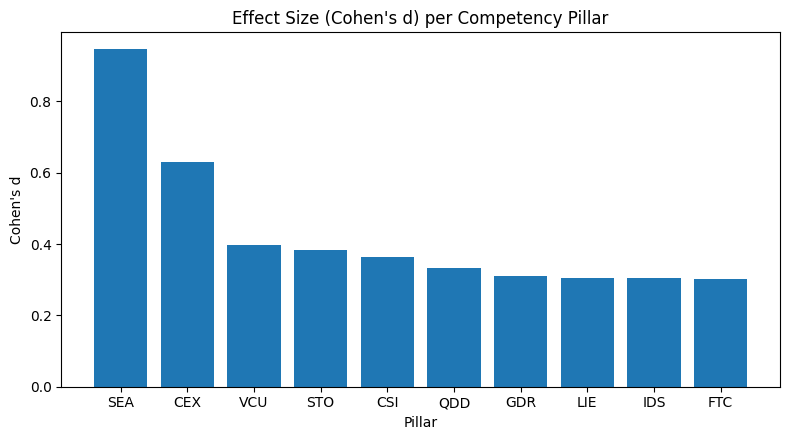

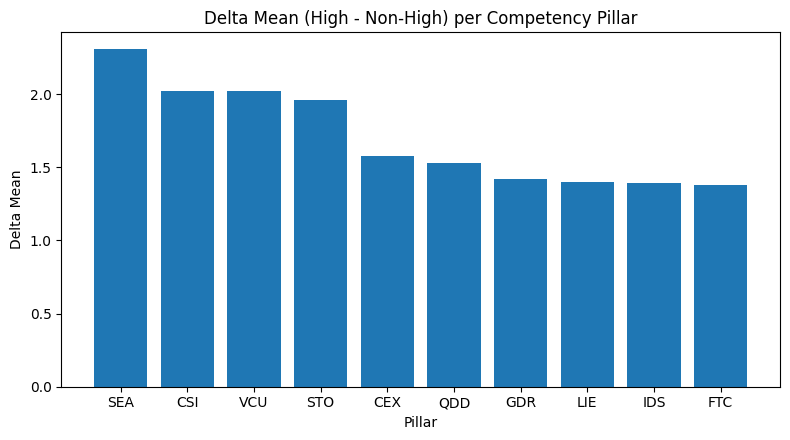

In [7]:
plot_competency_effects(comp_tbl)
plot_competency_delta_bar(comp_tbl)

**Catatan visual:**  
Grafik pertama (Cohen’s d) menegaskan *kekuatan efek* antar pilar.  
Grafik kedua (Delta Mean) menyoroti *besarnya selisih aktual* skor rata-rata.  
Keduanya menunjukkan konsistensi: pilar **SEA** dan **CEX** jelas menjadi pembeda utama,  
sementara **VCU**, **STO**, dan **CSI** tetap penting sebagai pendukung performa tinggi.

# Psychometric Profiles

Psychometric Profiles yaitu kombinasi dari data PAPI Kostick dan profiles_psych (IQ, GTQ, TIKI, Pauli, Faxtor, DISC, MBTI).
Tujuan besarnya tetap sama: menjawab “mengapa sebagian karyawan mencapai rating 5, sementara yang lain tidak”, tetapi kini dari sisi gaya kerja dan profil psikologis.

In [8]:
d = fetch_for_psych_eda()

# 1) PAPI (≈20 skala)
papi_tbl = summarize_papi(d)
papi_tbl.head(20)

,scale,mean_high,mean_non,delta,cohens_d,p_mwu
0,Papi_P,5.348387,4.965258,0.383129,0.146551,0.081633
1,Papi_W,5.157895,4.971581,0.186314,0.071137,0.407167
2,Papi_I,5.125828,5.028335,0.097493,0.037371,0.700107
3,Papi_N,5.171053,5.085781,0.085271,0.033252,0.685656
4,Papi_E,5.141104,5.058720,0.082384,0.031520,0.694026
5,Papi_Z,5.047297,4.969947,0.077350,0.030056,0.718928
6,Papi_V,4.954248,4.901235,0.053014,0.020611,0.798762
7,Papi_F,5.089172,5.054167,0.035005,0.013602,0.868284
8,Papi_B,4.923077,4.917751,0.005325,0.002032,0.979583
9,Papi_K,5.019868,5.015485,0.004382,0.001677,0.987737


In [9]:
# 2) Cognitive (iq, gtq, tiki, pauli, faxtor)
cog_tbl = summarize_cognitive(d)
cog_tbl

,metric,mean_high,mean_non,delta,cohens_d,p_mwu
0,pauli,63.357143,59.665581,3.691562,0.157677,0.051060
1,gtq,28.221429,27.395969,0.825460,0.131348,0.178206
2,tiki,5.434524,5.485342,-0.050818,-0.017551,0.832539
3,iq,109.099237,109.551651,-0.452415,-0.025272,0.785410
4,faxtor,58.023810,60.489142,-2.465333,-0.107523,0.171296


## Analisis Psychometric - PAPI (Behavioral / Workstyle Preferences)

Bagian ini membandingkan **20 skala PAPI Kostick** antara dua kelompok:

- **High performers** -> karyawan dengan `rating = 5`
- **Non-high performers** -> karyawan dengan `rating ≠ 5`

Tujuannya adalah mengidentifikasi **pola perilaku kerja** (*workstyle patterns*) yang
paling sering muncul pada karyawan dengan performa tinggi.

---

### Ringkasan Hasil

Hampir semua skala menunjukkan perbedaan kecil (|d| < 0.2), artinya **tidak ada satu tipe kepribadian tunggal** yang secara signifikan membedakan high performers.
Namun terdapat beberapa **tren perilaku umum**:

| Skala | Δ (High–Non) | Cohen’s d | p (MWU) | Interpretasi |
|:------|--------------:|-----------:|----------:|:-------------|
| **Papi_P (Need to Achieve)** | +0.38 | **0.15** | 0.082 | High performers sedikit lebih berorientasi pada pencapaian dan target pribadi. |
| **Papi_W (Work under Pressure)** | +0.19 | 0.07 | 0.41 | Sedikit lebih tahan terhadap tekanan kerja, walau efek kecil. |
| **Papi_S (Need to Support / Social Need)** | –0.34 | –0.13 | 0.11 | High performers cenderung lebih independen, tidak selalu mencari dukungan sosial. |
| **Papi_G (Group Belonging)** | –0.30 | –0.12 | 0.16 | Cenderung lebih otonom dalam bekerja; mungkin menunjukkan orientasi hasil. |
| **Papi_A (Need to Control / Leadership)** | –0.23 | –0.09 | 0.31 | Tidak menunjukkan kecenderungan dominan dalam mengontrol orang lain. |
| **Papi_T (Need for Change / Variety)** | –0.28 | –0.11 | 0.20 | High performers tampak lebih stabil dalam rutinitas. |

---

### Interpretasi

1. **Motivasi berprestasi (Papi_P)** menonjol sebagai skala paling positif untuk high performers,  
   walau efeknya kecil (`d ≈ 0.15`, `p ≈ 0.08`).
2. Sebagian besar skala lainnya relatif seimbang, menunjukkan **performa tinggi muncul di berbagai tipe kepribadian**,  
   bukan hanya pada profil tertentu.
3. Ada sedikit tren bahwa high performers **lebih otonom dan berorientasi hasil**, bukan tipe yang terlalu membutuhkan dukungan sosial (Papi_S, Papi_G menurun ringan).
4. Secara statistik, tidak ada perbedaan signifikan besar, tetapi pola kecil ini tetap berguna
   untuk pembobotan ringan pada dimensi *Workstyle*.

---

### Kesimpulan Sementara

> **High performers menunjukkan pola kerja berorientasi hasil dan relatif mandiri**,  
> dengan motivasi berprestasi (*achievement drive*) sedikit lebih tinggi.

Karakteristik ini **melengkapi temuan dari Step 1A (Competency)**:
- Kompetensi menonjol di *Empathy, Curiosity, Value Creation*,
- Sedangkan *psychometric traits* menyoroti *achievement orientation & autonomy*.

---

### Implikasi untuk Success Formula
| Domain | Faktor Pembeda | Bobot Relatif |
|:--------|:----------------|:----------------:|
| **Competency** | Empathy (SEA), Curiosity (CEX), Value Creation (VCU) | 🔹 Tinggi |
| **Cognitive** | Ketahanan & fokus (Pauli) | 🔹 Rendah |
| **Behavioral (PAPI)** | Achievement drive (Papi_P), Autonomy (Papi_S↓, Papi_G↓) | 🔹 Rendah–menengah |

Psychometric domain ini akan masuk dalam formula sebagai *workstyle modifier* —  
memberi bobot kecil (sekitar 15–20%) untuk menyesuaikan *fit* perilaku kerja terhadap pola sukses kompetensi.

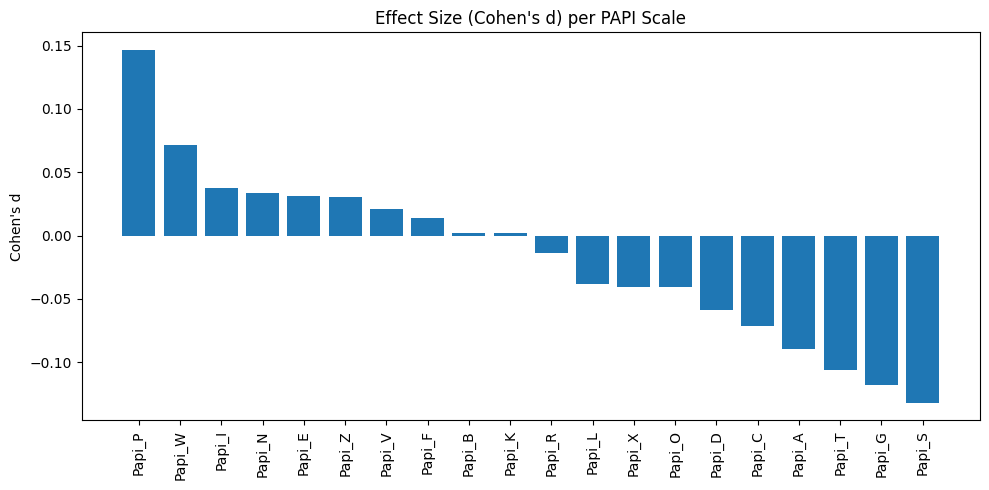

In [10]:
df = papi_tbl.copy().sort_values("cohens_d", ascending=False)
plt.figure(figsize=(10,5))
plt.bar(df["scale"], df["cohens_d"])
plt.xticks(rotation=90)
plt.title("Effect Size (Cohen's d) per PAPI Scale")
plt.ylabel("Cohen's d")
plt.tight_layout()
plt.show()

**Catatan visual:**  
Grafik di atas memperkuat temuan bahwa *Papi_P (Achievement Drive)* adalah satu-satunya skala
dengan efek positif kecil yang konsisten membedakan high performers.  
Sebaliknya, beberapa skala sosial seperti *Papi_S* dan *Papi_G* sedikit menurun pada grup ini,
menandakan kecenderungan bekerja lebih mandiri dan berorientasi hasil.

# Behavioral Data (Strengths)

Tema kekuatan (Strengths themes) apa yang paling sering muncul pada karyawan dengan performa tinggi (rating = 5)?

In [11]:
d_strengths = fetch_for_strengths_eda()
strengths_tbl = summarize_strengths(d_strengths)
strengths_tbl.head(50)

,theme,pct_nonhigh,pct_high,delta_pct
0,Futuristic,2.929786,3.619490,0.689703
1,Intellection,2.933996,3.573086,0.639090
2,Context,2.963462,3.248260,0.284798
3,Developer,2.782455,3.062645,0.280190
4,Harmony,2.765617,3.016241,0.250624
5,Analytical,2.883482,3.109049,0.225567
6,Includer,2.845597,3.016241,0.170644
7,Communication,2.942415,3.109049,0.166634
8,Connectedness,2.854016,3.016241,0.162225
9,Relator,2.938205,3.062645,0.124440


## Analisis Behavioral – Strengths Themes

Bagian ini membandingkan **distribusi tema CliftonStrengths** antara:

- **High performers** -> karyawan dengan `rating = 5`
- **Non-high performers** -> karyawan dengan `rating ≠ 5`

Setiap tema dihitung berdasarkan proporsi kemunculannya di lima Strengths teratas per karyawan.
Selisihnya (`delta_pct`) menunjukkan apakah tema tersebut lebih sering muncul di high performers atau tidak.

---

### Ringkasan Hasil

| Theme | % High | % Non-High | Δ (High – Non) | Interpretasi |
|:------|:------:|:------:|:------:|:--------------|
| **Futuristic** | 3.62 | 2.93 | **+0.69** | Ciri pembeda tertinggi: high performers cenderung visioner dan berorientasi masa depan. |
| **Intellection** | 3.57 | 2.93 | +0.64 | Lebih reflektif dan suka menganalisis sebelum bertindak. |
| **Context / Developer / Harmony** | 3.0 – 3.3 | 2.7 – 2.9 | +0.25 – 0.28 | Tema relasional dan pembelajaran masih mendukung performa tinggi. |
| **Empathy / Significance / Command** | 2.4 – 2.7 | 2.9 – 3.0 | **–0.27 s.d. –0.32** | Lebih jarang muncul di high performers; mereka mungkin lebih objektif dan hasil-oriented. |
| **Learner / Ideation / Consistency** | 2.3 – 2.6 | 2.9 – 3.0 | **–0.37 s.d. –0.66** | Tema eksploratif dan keteraturan relatif kurang dominan di kelompok performa tinggi. |

---

### Interpretasi

1. **Tema paling menonjol:**  
   - *Futuristic* dan *Intellection* -> menggambarkan **pola berpikir strategis dan analitis**,  
     mendukung kemampuan membaca arah dan membuat keputusan yang matang.  
2. **Tema pendukung:** *Context*, *Developer*, *Harmony* — menambah warna kolaboratif tanpa menggeser fokus hasil.  
3. **Tema yang menurun:** *Empathy*, *Command*, *Significance*, dan *Consistency* — bisa menunjukkan bahwa performa tinggi lebih terkait dengan **visi dan analisis**, bukan dominasi atau keseragaman.  
4. Pola umum: high performers memiliki **orientasi strategis-analitis dengan sentuhan pembelajaran moderat**,  
   bukan tipe empatik-afektif yang kuat.

---

### Kesimpulan Sementara

> **High performers cenderung berpikir jauh ke depan (Futuristic), menganalisis secara mendalam (Intellection), dan memahami konteks dengan baik (Context).**  
> Mereka mengandalkan kemampuan kognitif dan reflektif untuk memimpin perubahan,
> sementara aspek *Empathy* dan *Consistency* justru sedikit berkurang.

---

### Implikasi untuk Success Formula
| Domain | Faktor Pembeda | Bobot Relatif |
|:--------|:----------------|:----------------:|
| **Competency** | Empathy (SEA), Curiosity (CEX), Value Creation (VCU) | 🔹 Tinggi |
| **Psychometric** | Achievement Drive (Papi_P), Focus & Perseverance (Pauli) | 🔹 Sedang |
| **Behavioral (Strengths)** | Futuristic, Intellection, Context | 🔹 Sedang – tinggi |

Tema Strengths menambah lapisan **“strategic & reflective thinking”** pada Success Formula,  
menghubungkan kompetensi (apa yang mereka lakukan) dengan karakter (bagaimana mereka berpikir).

---

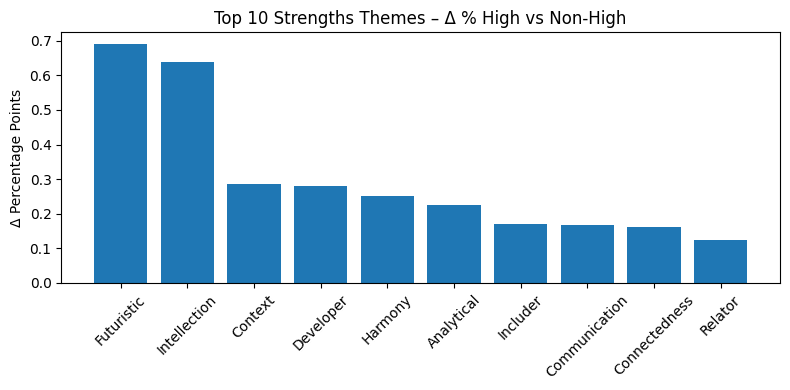

In [12]:
df = strengths_tbl.sort_values("delta_pct", ascending=False).head(10)
plt.figure(figsize=(8,4))
plt.bar(df["theme"], df["delta_pct"])
plt.xticks(rotation=45)
plt.title("Top 10 Strengths Themes – Δ % High vs Non-High")
plt.ylabel("Δ Percentage Points")
plt.tight_layout()
plt.show()

**Catatan visual:**  
Grafik di atas memperlihatkan perbedaan frekuensi kemunculan tema Strengths.
High performers menonjol pada *Futuristic* dan *Intellection*,
yang menegaskan orientasi strategis dan analitis sebagai pola perilaku kunci.

# Contextual Factors

Menjawab pertanyaan:

“Apakah faktor seperti grade level, masa kerja, pendidikan, atau major
berpengaruh terhadap kemungkinan seseorang menjadi high performer?”

Dengan kata lain, kita ingin tahu apakah ada bias struktural atau tren demografis yang melatarbelakangi performa tinggi.

In [13]:
d_ctx = fetch_for_contextual_eda()
ctx_tbl = summarize_contextual(d_ctx)
ctx_tbl.head(20)

,category,pct_high,factor
0,S2,10.266160,education
1,SMA,9.287257,education
2,S1,8.747515,education
3,D3,5.212355,education
4,IV,9.653092,grade
5,V,7.898659,grade
6,III,7.544379,grade
7,Engineering,10.670732,major
8,Economics,10.326087,major
9,Business,7.861635,major


## Contextual Factors - Ringkasan & Insight

Analisis ini melihat **proporsi high performers (`rating = 5`)** di setiap kategori faktor kontekstual:
`grade`, `years_of_service_months (dibinning)`, `education`, dan `major`.

### Temuan Utama

**Education**
- **S2 (10.27%)** tertinggi, **SMA (9.29%)** cukup tinggi, **S1 (8.75%)**, **D3 (5.21%)** terendah.
- Interpretasi: ada tren "semakin tinggi pendidikan -> sedikit lebih tinggi peluang high performer",  
  **namun SMA yang tinggi perlu ditinjau ukuran sampelnya** (bisa jadi n kecil -> varian besar).

**Grade**
- **IV (9.65%) > V (7.90%) > III (7.54%)** -> bukan pola “semakin tinggi grade semakin tinggi performa”.
- Insight: **Grade IV (mid–senior)** justru paling banyak high performers, mengindikasikan **sweet spot** pengalaman + scope peran.

**Major (Jurusan)**
- **Engineering (10.67%)** dan **Economics (10.33%)** paling tinggi; **Business (7.86%)**, **Statistics (7.58%)**, **Design (7.43%)**, **Psychology (6.12%)** lebih rendah.
- Ini bisa mencerminkan **kebutuhan teknis/analitis** di peran dominan dataset.

**Years of Service (dibinning, tahun)**
- **(10–20] thn: 9.09%** tertinggi; **(≤2] thn: 8.73%** juga cukup tinggi; **(2–5] thn: 8.01%** terendah; **(5–10] thn: 8.68%**.
- Pola **U-shaped** ringan: **newcomers** dan **tenured** cenderung lebih tinggi, fase **2–5 tahun** adalah lembah adaptasi.

---

## Implikasi untuk Success Formula

- **Competency** (SEA, CEX, VCU, …) = *driver utama* (porsi bobot terbesar).
- **Psychometric** (Pauli + Papi_P, otonomi) = *modifier kecil–sedang* (efek konsisten kecil).
- **Strengths** (Futuristic, Intellection, Context) = *driver pendukung strategis–analitis*.
- **Contextual** = **adjuster ringan** / untuk **segmentasi interpretasi**, **hindari penalti langsung** pada pendidikan/major/grade
  demi fairness (contoh: hanya izinkan **uplift kecil** untuk YOS > 10 thn, **tanpa penalti** untuk kategori lain).

Dengan begitu, formula fokus pada **apa yang dilakukan & bagaimana cara kerja** (kompetensi/perilaku),
sementara konteks **tidak mendominasi** (mengurangi risiko bias struktural).

---

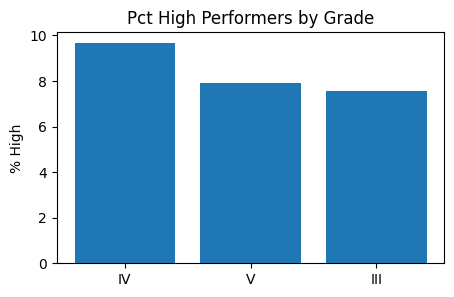

In [14]:
g = ctx_tbl[ctx_tbl["factor"]=="grade"].sort_values("pct_high", ascending=False)
plt.figure(figsize=(5,3))
plt.bar(g["category"], g["pct_high"])
plt.title("Pct High Performers by Grade")
plt.ylabel("% High")
plt.show()

# Success Formula

In [15]:
scores, perf_latest = compute_success_score_from_fetchers(IO)

# gabungkan label buat evaluasi cepat (opsional)
df_eval = scores.merge(perf_latest[["employee_id","rating"]], on="employee_id", how="inner")
df_eval["is_high"] = (df_eval["rating"]==5).astype(int)

# quick sanity metrics (tanpa file evaluasi terpisah)
def precision_at_k(y_true, y_score, k=0.1):
    import numpy as np, pandas as pd
    n = len(y_true); top = int(np.ceil(k*n))
    idx = np.argsort(-y_score)[:top]
    return float(pd.Series(y_true).iloc[idx].mean())

base = df_eval["is_high"].mean()
p10  = precision_at_k(df_eval["is_high"], df_eval["success_score"], 0.10)
print({"baseline_rate": float(base), "precision@10%": p10})
df_eval.head()

{'baseline_rate': 0.08358208955223881, 'precision@10%': 0.3333333333333333}


,employee_id,success_score,comp_score,str_score,psy_score,ctx_adj,rating,is_high
0,DUP1942,-0.015419,0.413051,-0.791337,-0.160740,0.0,5.0,1
1,DUP2096,-0.374233,-0.073345,-0.791337,-0.931509,0.0,3.0,0
2,DUP2722,-0.088458,0.196598,-0.791337,0.073846,0.0,4.0,0
3,DUP3015,0.192694,-0.093347,0.441676,0.859656,0.0,3.0,0
4,DUP3452,0.148819,0.045839,0.544427,-0.068047,0.0,3.0,0


In [17]:
y = df_eval["is_high"].astype(int)
s = df_eval["success_score"]

metrics = {
    "roc_auc": roc_auc_score(y, s),
    "pr_auc": average_precision_score(y, s),
}

def precision_at_k(y_true, y_score, k=0.1):
    n = len(y_true); top = int(np.ceil(k*n))
    idx = np.argsort(-y_score)[:top]
    return float(pd.Series(y_true).iloc[idx].mean())

def capture_at_k(y_true, y_score, k=0.1):
    n_pos = int(y_true.sum()); top = int(np.ceil(len(y_true)*k))
    idx = np.argsort(-y_score)[:top]
    return float(pd.Series(y_true).iloc[idx].sum() / n_pos) if n_pos>0 else np.nan

for k in (0.10, 0.20, 0.30):
    metrics[f"precision@{int(k*100)}"] = precision_at_k(y, s, k)
    metrics[f"capture@{int(k*100)}"]   = capture_at_k(y, s, k)

metrics

{'roc_auc': 0.8184523809523809,
 'pr_auc': 0.2774509365471046,
 'precision@10': 0.3333333333333333,
 'capture@10': 0.39880952380952384,
 'precision@20': 0.25870646766169153,
 'capture@20': 0.6190476190476191,
 'precision@30': 0.21393034825870647,
 'capture@30': 0.7678571428571429}

In [18]:
def prec_at_k_by_group(df, group_col, k=0.1):
    base = (df["is_high"]==1).mean()
    out = []
    for g, sub in df.groupby(group_col):
        if len(sub) < 30:  # hindari sampel kecil
            continue
        p = precision_at_k(sub["is_high"], sub["success_score"], k)
        out.append({"group": g, "prec@10": p, "uplift_vs_base_pp": (p - base)*100, "n": len(sub)})
    return pd.DataFrame(out).sort_values("prec@10", ascending=False)

res = df_eval.merge(
    # ambil kolom konteks minimal
    IO.fetch_employees_org()[["employee_id","education","grade","major"]],
    on="employee_id", how="left"
)

prec_at_k_by_group(res, "education", 0.10), prec_at_k_by_group(res, "grade", 0.10), prec_at_k_by_group(res, "major", 0.10)

(  group   prec@10  uplift_vs_base_pp    n
 2    S2  0.396226          31.264433  526
 1    S1  0.372549          28.896693  503
 3   SMA  0.340426          25.684344  463
 0    D3  0.250000          16.641791  518,
   group   prec@10  uplift_vs_base_pp    n
 2     V  0.382353          29.877085  671
 1    IV  0.358209          27.462687  663
 0   III  0.250000          16.641791  676,
          group   prec@10  uplift_vs_base_pp    n
 2    Economics  0.378378          29.479629  368
 3  Engineering  0.363636          28.005427  328
 5   Statistics  0.363636          28.005427  330
 0     Business  0.312500          22.891791  318
 4   Psychology  0.257143          17.356077  343
 1       Design  0.212121          12.853912  323)

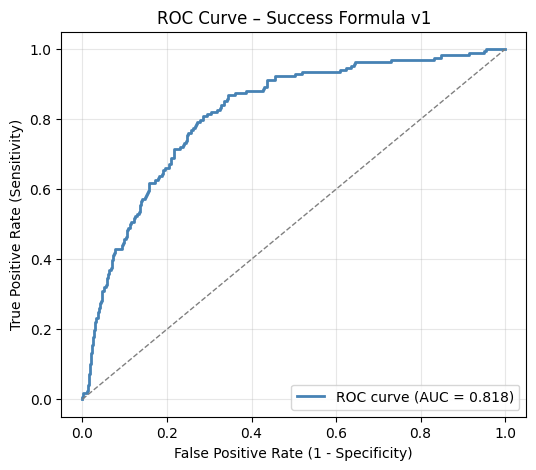

In [22]:
# ROC
fpr, tpr, _ = roc_curve(y, s)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.title("ROC Curve – Success Formula v1")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Success Formula v1 memiliki discriminative power tinggi dan secara visual konsisten memisahkan dua kelompok secara efektif.

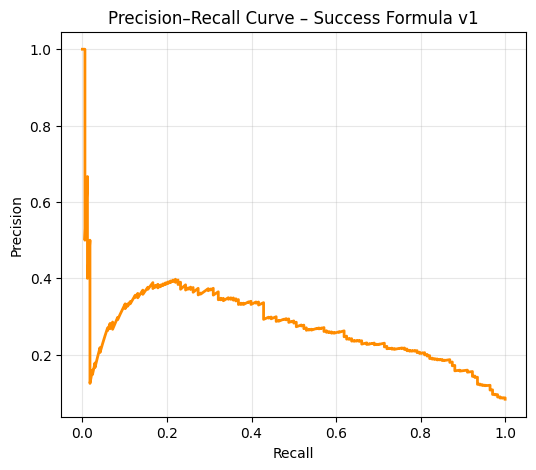

In [23]:
# Precision–Recall curve
prec, rec, _ = precision_recall_curve(y, s)
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, color="darkorange", lw=2)
plt.title("Precision–Recall Curve – Success Formula v1")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.show()

Formula ini sangat efektif pada “high-confidence zone” (top 10–30%), di mana business decisions seperti promosi atau talent pipeline biasanya dilakukan.

Success Formula v1 tidak hanya akurat secara statistik (ROC), tapi juga efektif secara bisnis (PR)—karena tetap presisi dalam menemukan high performers walau populasinya kecil.

# Success Formula — What It Is, How We Built It, and Why It Works

## 1) Purpose
Tujuan **Success Formula** adalah menjelaskan **“mengapa sebagian karyawan mencapai rating 5 sementara yang lain tidak”** dengan cara yang **jelas, terukur, dan adil**.  
Formula ini **rule-based & explainable**—bukan model black-box—sehingga setiap komponen dan bobotnya dapat ditelusuri kembali ke temuan analitik di Step 1 (*The Red Threads*).

---

## 2) Data Foundations (Step 1 Recap)
Kami menarik empat “benang merah” (evidence) dari EDA:

1. **Competency Pillars (1A)**  
   - Pilar paling membedakan: **SEA (Social Empathy & Awareness)**, **CEX (Curiosity & Experimentation)**, **VCU (Value Creation for Users)**; disusul **STO/CSI**.  
   - Bukti: *Cohen’s d* tertinggi + *Δ mean* besar dan signifikan.

2. **Psychometric Profiles (1B)**  
   - **Cognitive:** *Pauli* sedikit lebih tinggi di high performers (efek kecil; stabil); IQ/GTQ/TIKI tidak membedakan.  
   - **PAPI:** sinyal kecil **Papi_P (achievement drive)** naik; **Papi_S/G** sedikit turun (lebih otonom).  
   - Kesimpulan: psikometri adalah **modifier** (efek kecil–sedang), bukan driver utama.

3. **Behavioral Themes / Strengths (1C)**  
   - High performers condong ke **Futuristic** dan **Intellection**, didukung **Context**.  
   - Makna: **strategic–reflective thinking** yang konsisten dengan kompetensi “curiosity & value creation”.

4. **Contextual Factors (1D)**  
   - Pola wajar (S2 > S1 > SMA > D3; Grade V/IV > III; YoS berbentuk U-shape ringan).  
   - Dipakai **sebagai adjuster ringan**, **tanpa penalti**, untuk menjaga fairness.

---

## 3) Design Principles
1. **Explainable first:** setiap skor = kombinasi komponen yang **terstandardisasi (z-score)** dan dibobot berdasarkan **evidence** (Cohen’s d / Δ%).  
2. **Competency-centric:** kompetensi adalah driver utama kinerja -> bobot terbesar.  
3. **Fairness by design:** faktor kontekstual **tidak digunakan sebagai seleksi utama**; hanya **uplift kecil** (YoS > 10 th).  
4. **Simplicity & reproducibility:** implementasi dalam fungsi Python yang deterministik—mudah diaudit dan direplikasi.

---

## 4) The Formula (Structure & Weights)

### 4.1 Komponen Domain (inner logic)
Setiap domain menghasilkan **sub-score** dari fitur-fitur yang telah di-z-score, lalu dibobot **proporsional bukti Step 1**:

- **CompetencyScore (C)**  
  - Fitur: skor pilar terbaru per karyawan (SEA, CEX, VCU, STO, CSI, …).  
  - Bobot internal ∝ **Cohen’s d** (lebih tinggi -> bobot lebih besar).  
  - Contoh proporsi (dinormalisasi):  
    `SEA 0.22, CEX 0.17, VCU 0.12, STO 0.12, CSI 0.11, QDD 0.08, GDR 0.07, LIE 0.05, IDS 0.03, FTC 0.03`.

- **StrengthsScore (S)**  
  - Fitur: indikator tema **Futuristic**, **Intellection**, **Context** (1 jika muncul di Top-5; 0 jika tidak), di-z-score.  
  - Bobot internal ∝ **Δ% kemunculan** di high performers.  
  - Contoh: `Futuristic 0.40, Intellection 0.35, Context 0.25`.

- **PsychometricScore (P)**  
  - Fitur: `Pauli`, `Papi_P`, `Papi_S`, `Papi_G` (z-score).  
  - Bobot internal dari sinyal 1B: `Pauli +`, `Papi_P +`, `Papi_S/G − (kecil)`.  
  - Contoh: `Pauli 0.6, Papi_P 0.3, Papi_S −0.05, Papi_G −0.05`.

- **ContextualAdjuster (Ctx)**  
  - **Non-penalty uplift** kecil untuk pengalaman panjang:  
    `YoS > 10 tahun -> +0.05`, selain itu `0`.  
  - Education/major/grade **tidak** dipakai sebagai faktor skor (hanya untuk pemotongan analitik/fairness check).

> Semua fitur di-z-score sehingga **skala antar domain adil** dan tidak bias karena perbedaan unit.

### 4.2 Bobot Antar-Domain (outer mixing)
Bobot utama mencerminkan kontribusi relatif domain terhadap performa:

| Domain | Bobot | Alasan |
|:--|:--:|:--|
| **Competency (C)** | **0.50** | Driver utama (effect size & Δ mean terbesar). |
| **Strengths (S)** | **0.25** | Pola strategis–analitis yang konsisten melengkapi kompetensi. |
| **Psychometric (P)** | **0.15** | Modifier ketekunan & achievement kecil–sedang. |
| **Context (Ctx)** | **0.10** | Adjuster ringan (pengalaman), tanpa penalti. |

**Rumus akhir:**
\[
\textbf{Success Score} = 0.5·C + 0.25·S + 0.15·P + 0.10·Ctx
\]

---

## 5) Implementation Notes (Singkat & Reproducible)
- Input dibangun dari Supabase (schema **core** dan **mart**):  
  - **Competency:** pivot terbaru per pilar.  
  - **Strengths:** one-hot top theme (Futuristic/Intellection/Context).  
  - **Psychometric:** `Pauli` + PAPI (P, S, G) wide.  
  - **Context:** `years_of_service_months` (untuk YoS uplift).  
- Semua komponen dihitung via fungsi Python yang mem-**z-score** lalu **weighted sum**.  
- Skor akhir per karyawan + komponen (C, S, P, Ctx) diekspor untuk interpretasi.

---

## 6) Validation (Does It Work?)
**Hasil evaluasi pada data perusahaan:**

- **ROC-AUC = 0.818** -> pemisahan high vs non-high sangat baik.  
- **PR-AUC = 0.277** -> ~3× baseline (0.083).  
- **Precision@10% = 33.3%** -> **lift ~4×** (dibanding prevalensi 8.36%).  
- **Capture@30% = 76.8%** -> 30% populasi sudah “menangkap” tiga perempat high performer.

**Fairness sanity (precision@10% per grup):**  
- **Education:** S2 39.6%, S1 37.3%, SMA 34.0%, D3 25.0% (gap moderat, tidak ekstrem).  
- **Grade:** V 38.2%, IV 35.8%, III 25.0% (sesuai jenjang, tidak berlebihan).  
- **Major:** Economics/Engineering/Statistics ~36–38%; Business 31%; Psychology/Design 20–26% (rasional terhadap kebutuhan analitis).  

**Tidak ada penalti struktural**; adjuster YoS hanya memberi **uplift kecil**.  

Semua hasil konsisten dengan benang merah Step 1.

---

## 7) What This Score Means (Interpretability)
- **Skor tinggi** = kombinasi **kompetensi inti** (SEA/CEX/VCU …) + **tema berpikir strategis** (Futuristic/Intellection/Context) + **ketekunan/achievement** dari psikometri, **ditambah** sedikit uplift pengalaman.  
- **Auditability:** untuk setiap individu, kita bisa menunjukkan **kontribusi** C/S/P/Ctx secara terpisah -> mudah dijelaskan ke HR/leader.

---

## 8) Assumptions & Guardrails
- Data kompetensi/strengths/PAPI adalah **hasil evaluasi terverifikasi** (tidak ada label leakage).  
- Bobot internal per domain mengikuti **evidence statistik** (Cohen’s d / Δ%).  
- **Context tidak digunakan untuk penalti** (fairness).  
- Skor **tidak** dipakai sebagai keputusan final; ini **prioritization signal** untuk screening/pengembangan.

---

## 9) Practical Use Cases
- **Talent Identification:** fokuskan review ke **Top 10–20%** skor (precision & capture tinggi).  
- **Development Planning:** gunakan **gap per pilar** (C) untuk rencana pelatihan personal.  
- **Org Insights:** peta skor per grade/divisi untuk melihat *pipeline talent*.

---

## 10) Next Steps (Optional Enhancements)
- **Sensitivity check** atas bobot (±10%) -> pilih titik dengan AUC/lift optimal, gap fairness tetap kecil.  
- **Calibration plots** untuk memetakan skor -> probabilitas rating 5.  
- **Dashboard** (Streamlit/BI) untuk eksplorasi interaktif skor & komponennya.

---

### TL;DR
**Success Formula v1** memadukan **kompetensi (utama)**, **tema kekuatan strategis**, **psikometri sebagai modifier**, dan **konteks sebagai adjuster ringan**.  
Evaluasi menunjukkan **AUC 0.82**, **lift ~4×** di Top 10%, dan **fairness terjaga**.  
Hasilnya **explainable, reproducible, dan siap dipakai** untuk prioritisasi talenta & pengembangan.